In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/accidents_processed.csv')

df['high_risk'] = (df['Severity'] >= 3).astype(int)

X = df.drop(['Severity','high_risk','cluster'], axis=1, errors='ignore')
y = df['high_risk']

X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)

In [7]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
# 🔥 Probability prediction (NEW)
y_proba_rf = rf.predict_proba(X_test)

# Extract probability of high risk (class = 1)
risk_scores = y_proba_rf[:, 1]

print("Random Forest Classification Report:\n")
print(classification_report(y_test, y_pred_rf))
# 🔥 Combine predictions + probabilities
results_df = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred_rf,
    'Risk_Probability': risk_scores
})

print("\nSample Predictions with Probability:")
print(results_df.head())

Random Forest Classification Report:

              precision    recall  f1-score   support

           0       0.61      0.66      0.64      8257
           1       0.54      0.49      0.52      6752

    accuracy                           0.59     15009
   macro avg       0.58      0.58      0.58     15009
weighted avg       0.58      0.59      0.58     15009


Sample Predictions with Probability:
   Actual  Predicted  Risk_Probability
0       0          1          0.880000
1       0          0          0.275833
2       0          0          0.278333
3       0          0          0.410000
4       1          1          0.843333


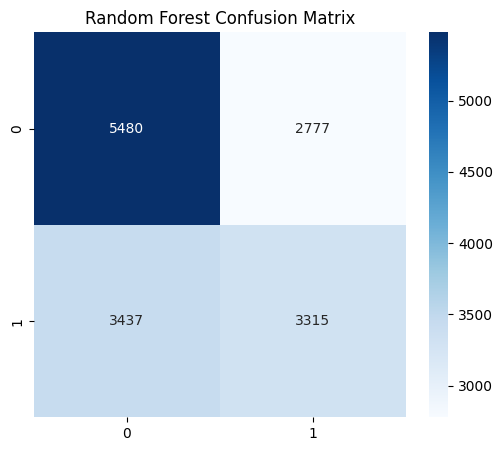

In [4]:
plt.figure(figsize=(6,5))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Blues')
plt.title("Random Forest Confusion Matrix")
plt.savefig('../results/confusion_rf.png', bbox_inches='tight')
plt.show()

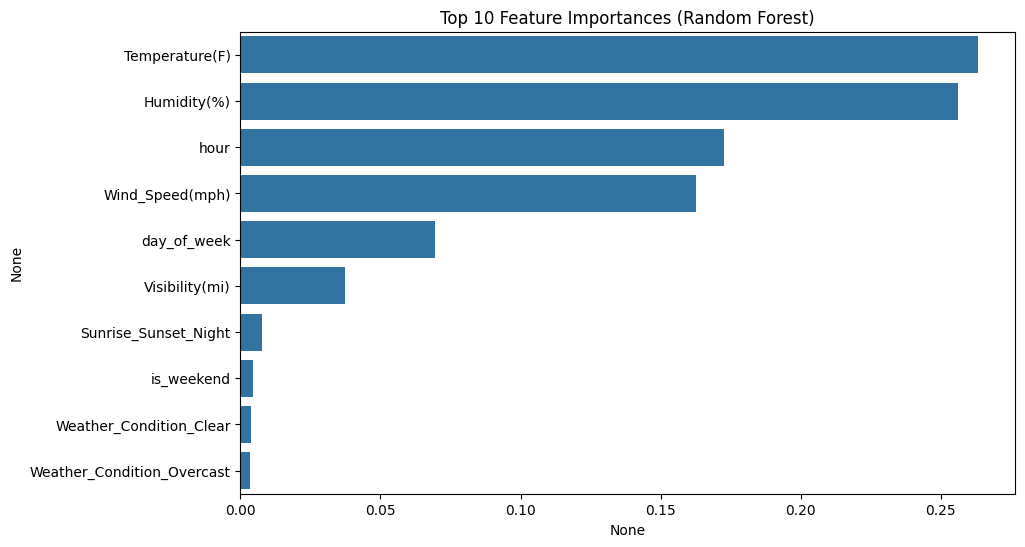

In [5]:
importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(x=importances[:10], y=importances.index[:10])
plt.title("Top 10 Feature Importances (Random Forest)")
plt.savefig('../results/feature_importance_rf.png', bbox_inches='tight')
plt.show()

In [6]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree Classification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Classification Report:

              precision    recall  f1-score   support

           0       0.60      0.62      0.61      8257
           1       0.51      0.49      0.50      6752

    accuracy                           0.56     15009
   macro avg       0.56      0.55      0.55     15009
weighted avg       0.56      0.56      0.56     15009



In [8]:
print("\nHigh confidence risky cases (>0.8):")
print(results_df[results_df['Risk_Probability'] > 0.8].head())

print("\nUncertain cases (0.4 - 0.6):")
print(results_df[(results_df['Risk_Probability'] > 0.4) & 
                 (results_df['Risk_Probability'] < 0.6)].head())


High confidence risky cases (>0.8):
    Actual  Predicted  Risk_Probability
0        0          1          0.880000
4        1          1          0.843333
8        1          1          0.832000
12       1          1          0.952500
18       0          1          0.855000

Uncertain cases (0.4 - 0.6):
    Actual  Predicted  Risk_Probability
3        0          0          0.410000
5        0          1          0.520000
7        0          0          0.426500
11       0          0          0.430000
13       1          0          0.464833


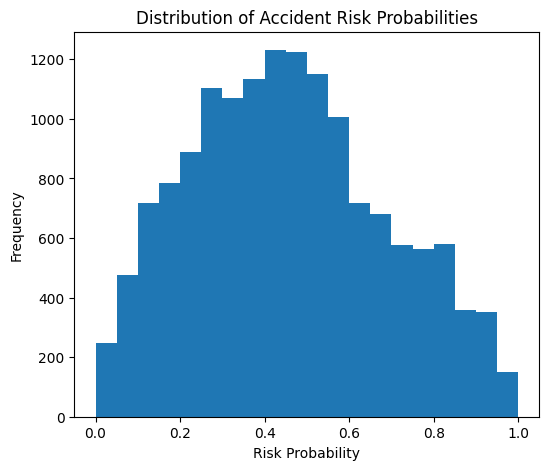

In [9]:
plt.figure(figsize=(6,5))
plt.hist(risk_scores, bins=20)
plt.title("Distribution of Accident Risk Probabilities")
plt.xlabel("Risk Probability")
plt.ylabel("Frequency")
plt.savefig('../results/risk_probability_distribution.png', bbox_inches='tight')
plt.show()